In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_simload
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc
import cosmo as co

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
# DF_fid = jsm_ancillary.load_massspec("../../data/vdb/DF_fid/", "artificial", 0)
# DF_fid.to_csv("../../data/vdb/DF_fid/artificial.csv")

# DF_fid = jsm_ancillary.load_massspec("../../data/zhao/DF_fid/", "artificial", 0)
# DF_fid.to_csv("../../data/zhao/DF_fid/artificial.csv")

In [5]:
zhao_pd = pd.read_csv("../../data/zhao/DF_fid/artificial.csv")
vdb_pd = pd.read_csv("../../data/vdb/DF_fid/artificial.csv")
bol_pd = pd.read_csv("../../data/summary_tabs/BolshoiP.csv")

In [6]:
zhao_pd = zhao_pd[zhao_pd["logMvir"] > 12.5]
vdb_pd = vdb_pd[vdb_pd["logMvir"] > 12.5]

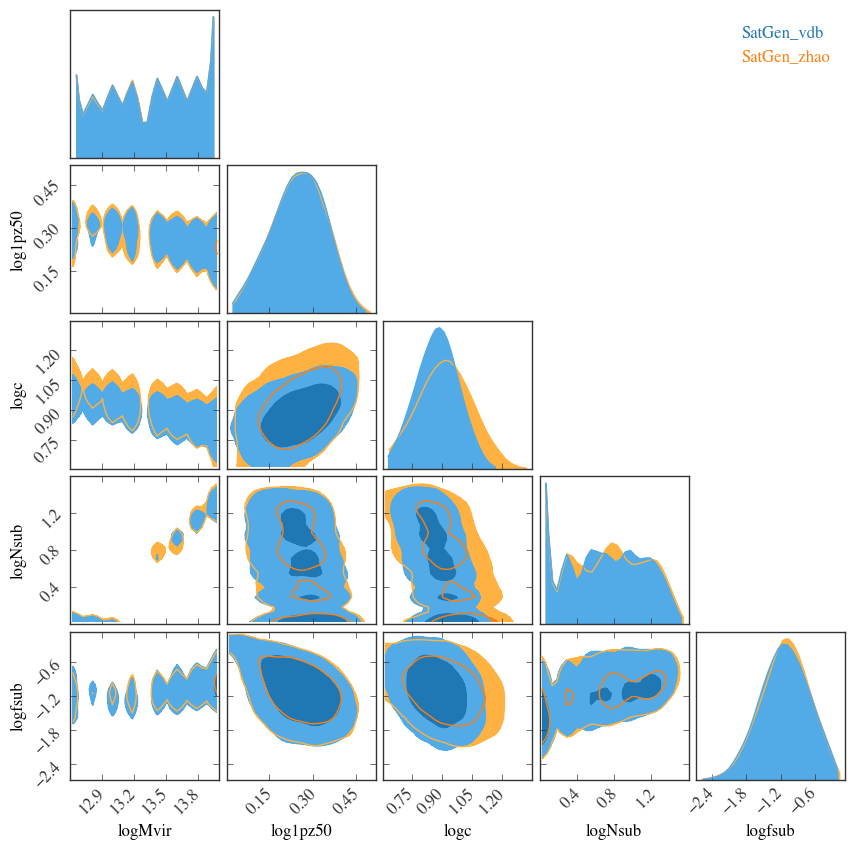

In [ ]:
corner_comp = pygtc.plotGTC(
    chains=[vdb_pd.dropna()[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]], zhao_pd.dropna()[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]],
    chainLabels=["SatGen_vdb", "SatGen_zhao"],
    smoothingKernel=1.4,
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12}, 
    mathTextFontSet=None,
    panelSpacing='loose',
    colorsOrder=["blues", "oranges"])

In [8]:
zhaonorm = jsm_simload.NormalizeData(zhao_pd, dataset_title="Zhao et al.")
vdbnorm = jsm_simload.NormalizeData(vdb_pd, dataset_title="vdB et al.")
bolnorm = jsm_simload.NormalizeData(bol_pd, dataset_title="BolshoiP")

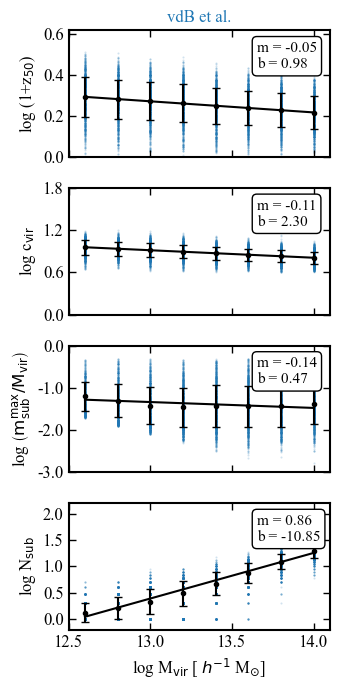

In [9]:
vdbnorm.plot_bestfit()

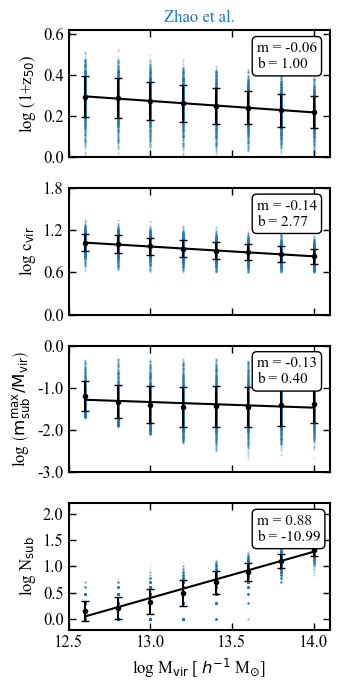

In [10]:
zhaonorm.plot_bestfit()

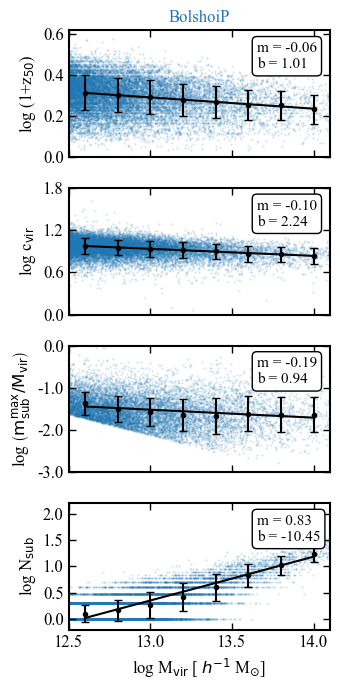

In [11]:
bolnorm.plot_bestfit()

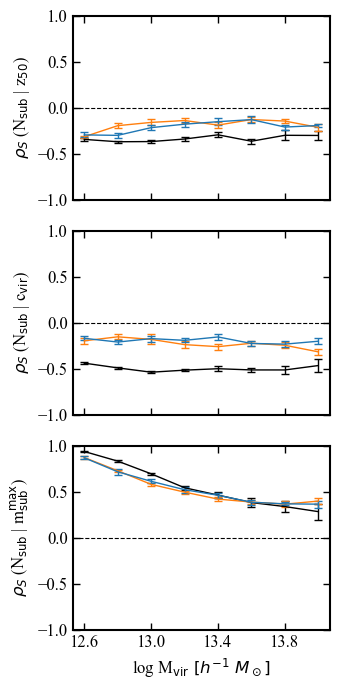

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [bolnorm, zhaonorm, vdbnorm]
colors = ["k", "C1", "C0"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])

plt.tight_layout()
# plt.savefig("../../figures/DF_rho.pdf", bbox_inches="tight")
plt.show()

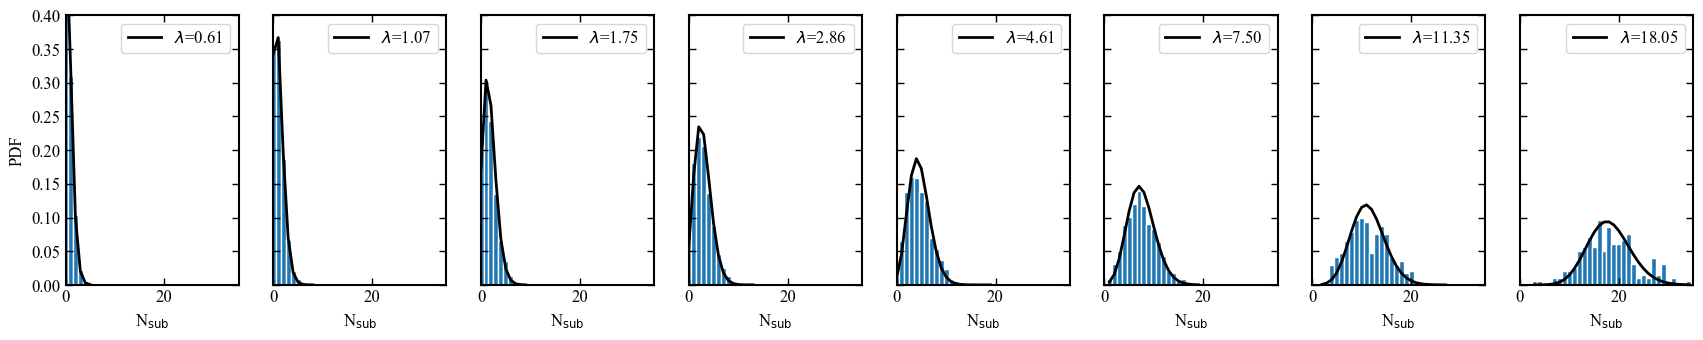

In [13]:
bolnorm.plot_poisson()

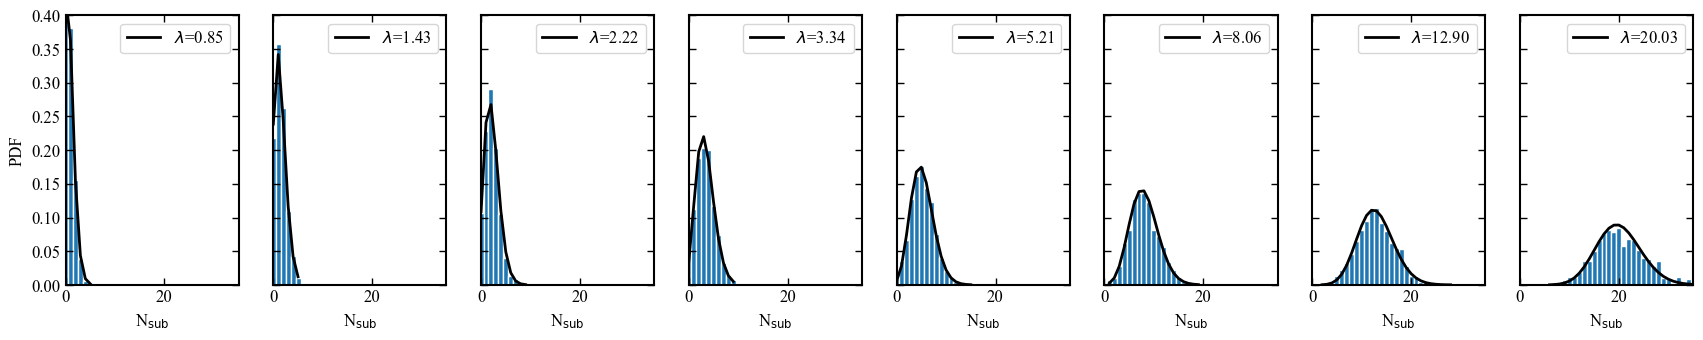

In [14]:
vdbnorm.plot_poisson()

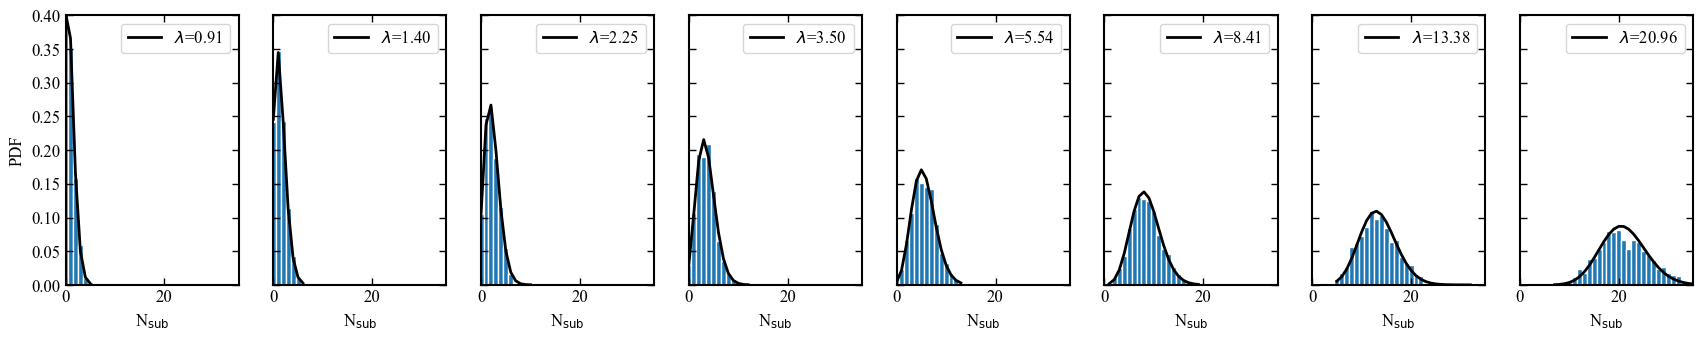

In [15]:
zhaonorm.plot_poisson()

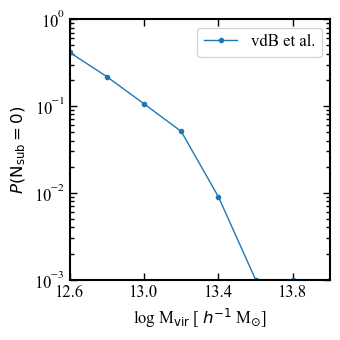

In [16]:
vdbnorm.plot_P0()

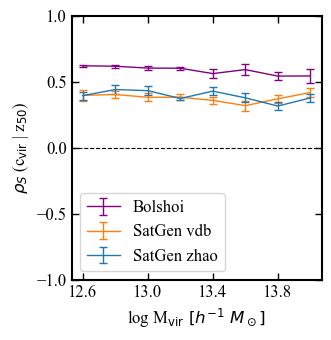

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(single_textwidth, single_textwidth), sharex=True, sharey=True)

datasets = [bolnorm, vdbnorm, zhaonorm]
colors = ["purple", "C1", "C0"]
labels = ["Bolshoi", "SatGen vdb", "SatGen zhao"]

for i,dataset in enumerate(datasets):
    axes.errorbar(dataset.logMvir_bincenters, dataset.rhocz_mat, yerr=dataset.rhocz_err_mat, color=colors[i], capsize=3, lw=1, label=labels[i])

axes.set_ylim(-1, 1)
axes.axhline(0, color="k", lw=0.8, ls="--")

axes.set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")
axes.set_ylabel("$\\rho_S$ (c$_{\\rm vir}$ | z$_{50}$)")
axes.legend()
axes.set_xticks([12.6, 13.0, 13.4, 13.8])

plt.tight_layout()
# plt.savefig("../../figures/DF_rho.pdf", bbox_inches="tight")
plt.show()

<Axes: xlabel='logc', ylabel='log1pz50'>

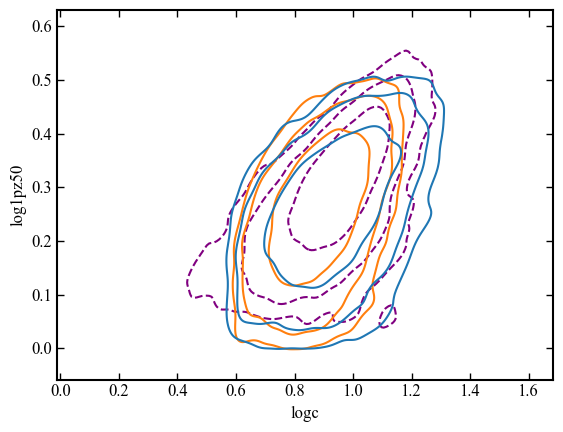

In [18]:
sns.kdeplot(x=bolnorm.df["logc"], y=bolnorm.df["log1pz50"], levels=levelz, color="purple", linestyles="--")
sns.kdeplot(x=vdbnorm.df["logc"], y=vdbnorm.df["log1pz50"], levels=levelz, color="C1")
sns.kdeplot(x=zhaonorm.df["logc"], y=zhaonorm.df["log1pz50"], levels=levelz, color="C0")

<Axes: xlabel='logc', ylabel='log1pz50'>

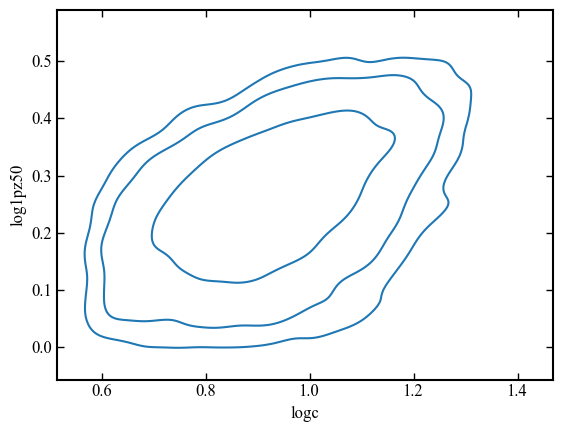

In [19]:
sns.kdeplot(x=zhaonorm.df["logc"], y=zhaonorm.df["log1pz50"], levels=levelz)

In [20]:
data_13_2z = jsm_ancillary.load_sample("../../data/zhao/DF_fid/12.4_files.h5")
data_13_2v = jsm_ancillary.load_sample("../../data/vdb/DF_fid/12.4_files.h5")

In [21]:
concentrations_z = jsm_ancillary.make_matrix(data_13_2z, "host_c")
concentrations_v = jsm_ancillary.make_matrix(data_13_2v, "host_c")

zsample = np.array([0.00000000e+00, 4.30881684e-03, 8.64468153e-03, 1.30078715e-02,
       1.73987469e-02, 2.18175685e-02, 2.62646870e-02, 3.07404080e-02,
       3.52450566e-02, 3.97789780e-02, 4.43424954e-02, 4.89359668e-02,
       5.35597393e-02, 5.82141550e-02, 6.28996116e-02, 6.76164259e-02,
       7.23650328e-02, 7.71457928e-02, 8.19590590e-02, 8.68052899e-02,
       9.16848731e-02, 9.65981966e-02, 1.01545665e-01, 1.06527762e-01,
       1.11544910e-01, 1.16597540e-01, 1.21686098e-01, 1.26811040e-01,
       1.31972836e-01, 1.37171965e-01, 1.42408918e-01, 1.47684196e-01,
       1.52998310e-01, 1.58351780e-01, 1.63745134e-01, 1.69178908e-01,
       1.74653643e-01, 1.80169890e-01, 1.85728199e-01, 1.91329178e-01,
       1.96973445e-01, 2.02661573e-01, 2.08394140e-01, 2.14171867e-01,
       2.19995341e-01, 2.25865218e-01, 2.31782198e-01, 2.37746915e-01,
       2.43760126e-01, 2.49822499e-01, 2.55934782e-01, 2.62097734e-01,
       2.68312059e-01, 2.74578596e-01, 2.80898134e-01, 2.87271457e-01,
       2.93699378e-01, 3.00182755e-01, 3.06722490e-01, 3.13319459e-01,
       3.19974562e-01, 3.26688719e-01, 3.33462873e-01, 3.40297982e-01,
       3.47195064e-01, 3.54155159e-01, 3.61179288e-01, 3.68268482e-01,
       3.75423834e-01, 3.82646514e-01, 3.89937582e-01, 3.97298290e-01,
       4.04729761e-01, 4.12233298e-01, 4.19810069e-01, 4.27461446e-01,
       4.35188733e-01, 4.42993248e-01, 4.50876366e-01, 4.58839535e-01,
       4.66884238e-01, 4.75011958e-01, 4.83224219e-01, 4.91522613e-01,
       4.99908793e-01, 5.08384406e-01, 5.16951115e-01, 5.25610674e-01,
       5.34364944e-01, 5.43215667e-01, 5.52164870e-01, 5.61214421e-01,
       5.70366321e-01, 5.79622704e-01, 5.88985658e-01, 5.98457351e-01,
       6.08040031e-01, 6.17736012e-01, 6.27547668e-01, 6.37477422e-01,
       6.47527775e-01, 6.57701430e-01, 6.68000950e-01, 6.78429179e-01,
       6.88988832e-01, 6.99682979e-01, 7.10514592e-01, 7.21486762e-01,
       7.32602701e-01, 7.43865729e-01, 7.55279258e-01, 7.66846775e-01,
       7.78571998e-01, 7.90458684e-01, 8.02510705e-01, 8.14732040e-01,
       8.27126957e-01, 8.39699719e-01, 8.52454762e-01, 8.65396679e-01,
       8.78530187e-01, 8.91860362e-01, 9.05392232e-01, 9.19131146e-01,
       9.33082510e-01, 9.47252054e-01, 9.61645722e-01, 9.76269661e-01,
       9.91130292e-01, 1.00623414e+00, 1.02158812e+00, 1.03719925e+00,
       1.05307510e+00, 1.06922335e+00, 1.08565200e+00, 1.10236955e+00,
       1.11938455e+00, 1.13670621e+00, 1.15434394e+00, 1.17230760e+00,
       1.19060749e+00, 1.20925427e+00, 1.22825936e+00, 1.24763442e+00,
       1.26739172e+00, 1.28754407e+00, 1.30810486e+00, 1.32908829e+00,
       1.35050909e+00, 1.37238268e+00, 1.39472523e+00, 1.41755394e+00,
       1.44088666e+00, 1.46474215e+00, 1.48914014e+00, 1.51410167e+00,
       1.53964861e+00, 1.56580402e+00, 1.59259252e+00, 1.62003977e+00,
       1.64817309e+00, 1.67702114e+00, 1.70658071e+00, 1.73644201e+00,
       1.76660857e+00, 1.79708395e+00, 1.82787171e+00, 1.85897567e+00,
       1.89039957e+00, 1.92214703e+00, 1.95422174e+00, 1.98662777e+00,
       2.01936884e+00, 2.05244865e+00, 2.08587146e+00, 2.11964102e+00,
       2.15376128e+00, 2.18823646e+00, 2.22307037e+00, 2.25826737e+00,
       2.29383146e+00, 2.32976682e+00, 2.36607778e+00, 2.40276841e+00,
       2.43984327e+00, 2.47730642e+00, 2.51516258e+00, 2.55341582e+00,
       2.59207101e+00, 2.63113230e+00, 2.67060459e+00, 2.71049221e+00,
       2.75080004e+00, 2.79153262e+00, 2.83269478e+00, 2.87429133e+00,
       2.91632695e+00, 2.95880682e+00, 3.00173553e+00, 3.04511844e+00,
       3.08896037e+00, 3.13326641e+00, 3.17804188e+00, 3.22329164e+00,
       3.26902133e+00, 3.31523607e+00, 3.36194106e+00, 3.40914207e+00,
       3.45684427e+00, 3.50505326e+00, 3.55377477e+00, 3.60301414e+00,
       3.65277731e+00, 3.70307005e+00, 3.75389787e+00, 3.80526698e+00,
       3.85718325e+00, 3.90965241e+00, 3.96268084e+00, 4.01627462e+00,
       4.07043967e+00, 4.12518247e+00, 4.18050941e+00, 4.23642659e+00,
       4.29294055e+00, 4.35005804e+00, 4.40778538e+00, 4.46612906e+00,
       4.52509630e+00, 4.58469364e+00, 4.64492768e+00, 4.70580572e+00,
       4.76733476e+00, 4.82952164e+00, 4.89237346e+00, 4.95589786e+00,
       5.02010191e+00, 5.08499274e+00, 5.15057816e+00, 5.21686575e+00,
       5.28386289e+00, 5.35157704e+00, 5.42001662e+00, 5.48918926e+00,
       5.55910265e+00, 5.62976484e+00, 5.70118436e+00, 5.77336916e+00,
       5.84632727e+00, 5.92006731e+00, 5.99459795e+00, 6.06992751e+00,
       6.14606438e+00, 6.22301766e+00, 6.30079629e+00, 6.37940894e+00,
       6.45886437e+00, 6.53917216e+00, 6.62034154e+00, 6.70238159e+00,
       6.78530145e+00, 6.86911110e+00, 6.95382020e+00, 7.03943819e+00,
       7.12597464e+00, 7.21343991e+00, 7.30184412e+00, 7.39119714e+00,
       7.48150893e+00, 7.57279023e+00, 7.66505169e+00, 7.75830361e+00,
       7.85255640e+00, 7.94782110e+00, 8.04410897e+00, 8.14143077e+00,
       8.23979738e+00, 8.33922011e+00, 8.43971091e+00, 8.54128102e+00,
       8.64394178e+00, 8.74770475e+00, 8.85258265e+00, 8.95858721e+00,
       9.06573029e+00, 9.17402385e+00, 9.28348103e+00, 9.39411431e+00,
       9.50593605e+00, 9.61895874e+00, 9.73319575e+00, 9.84866044e+00,
       9.96536572e+00, 1.00833246e+01, 1.02025507e+01, 1.03230584e+01,
       1.04448610e+01, 1.05679722e+01, 1.06924059e+01, 1.08181772e+01,
       1.09453002e+01, 1.10737894e+01, 1.12036588e+01, 1.13349241e+01,
       1.14676005e+01, 1.16017028e+01, 1.17372460e+01, 1.18742456e+01,
       1.20127182e+01, 1.21526793e+01, 1.22941444e+01, 1.24371295e+01,
       1.25816519e+01, 1.27277280e+01, 1.28753742e+01, 1.30246069e+01,
       1.31754437e+01, 1.33279024e+01, 1.34819999e+01, 1.36377536e+01,
       1.37951809e+01, 1.39543012e+01, 1.41151323e+01, 1.42776921e+01,
       1.44419988e+01, 1.46080720e+01, 1.47759310e+01, 1.49455945e+01,
       1.51170816e+01, 1.52904118e+01, 1.54656060e+01, 1.56426839e+01,
       1.58216652e+01, 1.60025701e+01, 1.61854202e+01, 1.63702366e+01,
       1.65570399e+01, 1.67458510e+01, 1.69366918e+01, 1.71295850e+01,
       1.73245522e+01, 1.75216153e+01, 1.77207962e+01, 1.79221193e+01,
       1.81256073e+01, 1.83312830e+01, 1.85391694e+01, 1.87492909e+01,
       1.89616722e+01, 1.91763370e+01, 1.93933095e+01, 1.96126139e+01,
       1.98342772e+01, 2.00583242e+01])

vsample = np.array([0.00000000e+00, 4.17305120e-03, 8.37166325e-03, 1.25961148e-02,
       1.68466876e-02, 2.11236668e-02, 2.54273400e-02, 2.97579973e-02,
       3.41159308e-02, 3.85014433e-02, 4.29148898e-02, 4.73565741e-02,
       5.18268003e-02, 5.63258726e-02, 6.08541854e-02, 6.54120577e-02,
       6.99997996e-02, 7.46178078e-02, 7.92664302e-02, 8.39459856e-02,
       8.86569225e-02, 9.33995540e-02, 9.81743091e-02, 1.02981545e-01,
       1.07821686e-01, 1.12695108e-01, 1.17602262e-01, 1.22543505e-01,
       1.27519350e-01, 1.32530178e-01, 1.37576434e-01, 1.42658610e-01,
       1.47777129e-01, 1.52932436e-01, 1.58125082e-01, 1.63355529e-01,
       1.68624261e-01, 1.73931772e-01, 1.79278575e-01, 1.84665218e-01,
       1.90092250e-01, 1.95560213e-01, 2.01069661e-01, 2.06621161e-01,
       2.12215288e-01, 2.17852630e-01, 2.23533797e-01, 2.29259437e-01,
       2.35030175e-01, 2.40846640e-01, 2.46709467e-01, 2.52619313e-01,
       2.58576932e-01, 2.64582978e-01, 2.70638131e-01, 2.76743200e-01,
       2.82898845e-01, 2.89105900e-01, 2.95365069e-01, 3.01677221e-01,
       3.08043077e-01, 3.14463555e-01, 3.20939464e-01, 3.27471623e-01,
       3.34060982e-01, 3.40708444e-01, 3.47414913e-01, 3.54181328e-01,
       3.61008652e-01, 3.67897880e-01, 3.74850030e-01, 3.81866145e-01,
       3.88947288e-01, 3.96094541e-01, 4.03308999e-01, 4.10591769e-01,
       4.17944087e-01, 4.25367137e-01, 4.32862068e-01, 4.40430236e-01,
       4.48072839e-01, 4.55791264e-01, 4.63586755e-01, 4.71460823e-01,
       4.79414825e-01, 4.87450177e-01, 4.95568386e-01, 5.03771028e-01,
       5.12059654e-01, 5.20435863e-01, 5.28901297e-01, 5.37457635e-01,
       5.46106651e-01, 5.54850169e-01, 5.63689985e-01, 5.72627921e-01,
       5.81666052e-01, 5.90806220e-01, 6.00050629e-01, 6.09401283e-01,
       6.18860332e-01, 6.28430092e-01, 6.38112821e-01, 6.47910867e-01,
       6.57826651e-01, 6.67862664e-01, 6.78021450e-01, 6.88305701e-01,
       6.98718188e-01, 7.09261611e-01, 7.19939001e-01, 7.30753208e-01,
       7.41707434e-01, 7.52804834e-01, 7.64048662e-01, 7.75442301e-01,
       7.86989249e-01, 7.98693099e-01, 8.10557521e-01, 8.22586486e-01,
       8.34783893e-01, 8.47153900e-01, 8.59700661e-01, 8.72428648e-01,
       8.85342423e-01, 8.98446658e-01, 9.11746188e-01, 9.25246194e-01,
       9.38951824e-01, 9.52868474e-01, 9.67001749e-01, 9.81357556e-01,
       9.95941894e-01, 1.01076102e+00, 1.02582140e+00, 1.04112986e+00,
       1.05669343e+00, 1.07251940e+00, 1.08861531e+00, 1.10498907e+00,
       1.12164897e+00, 1.13860357e+00, 1.15586164e+00, 1.17343267e+00,
       1.19132622e+00, 1.20955242e+00, 1.22812180e+00, 1.24704529e+00,
       1.26633454e+00, 1.28600143e+00, 1.30605856e+00, 1.32651914e+00,
       1.34739686e+00, 1.36870617e+00, 1.39046212e+00, 1.41268062e+00,
       1.43537828e+00, 1.45857250e+00, 1.48228159e+00, 1.50652496e+00,
       1.53132291e+00, 1.55669668e+00, 1.58266883e+00, 1.60926318e+00,
       1.63650459e+00, 1.66441971e+00, 1.69303631e+00, 1.72238426e+00,
       1.75238321e+00, 1.78268945e+00, 1.81330670e+00, 1.84423868e+00,
       1.87548898e+00, 1.90706120e+00, 1.93895933e+00, 1.97118707e+00,
       2.00374810e+00, 2.03664649e+00, 2.06988607e+00, 2.10347055e+00,
       2.13740428e+00, 2.17169100e+00, 2.20633483e+00, 2.24133990e+00,
       2.27671014e+00, 2.31244999e+00, 2.34856333e+00, 2.38505476e+00,
       2.42192823e+00, 2.45918835e+00, 2.49683922e+00, 2.53488551e+00,
       2.57333139e+00, 2.61218165e+00, 2.65144049e+00, 2.69111288e+00,
       2.73120306e+00, 2.77171609e+00, 2.81265640e+00, 2.85402893e+00,
       2.89583844e+00, 2.93808969e+00, 2.98078783e+00, 3.02393746e+00,
       3.06754402e+00, 3.11161232e+00, 3.15614747e+00, 3.20115482e+00,
       3.24663928e+00, 3.29260645e+00, 3.33906153e+00, 3.38600967e+00,
       3.43345676e+00, 3.48140799e+00, 3.52986886e+00, 3.57884528e+00,
       3.62834261e+00, 3.67836664e+00, 3.72892334e+00, 3.78001830e+00,
       3.83165747e+00, 3.88384703e+00, 3.93659273e+00, 3.98990068e+00,
       4.04377731e+00, 4.09822856e+00, 4.15326060e+00, 4.20888020e+00,
       4.26509351e+00, 4.32190676e+00, 4.37932699e+00, 4.43736066e+00,
       4.49601418e+00, 4.55529452e+00, 4.61520865e+00, 4.67576320e+00,
       4.73696500e+00, 4.79882159e+00, 4.86133985e+00, 4.92452672e+00,
       4.98838973e+00, 5.05293634e+00, 5.11817374e+00, 5.18410916e+00,
       5.25075080e+00, 5.31810611e+00, 5.38618258e+00, 5.45498803e+00,
       5.52453078e+00, 5.59481857e+00, 5.66585924e+00, 5.73766116e+00,
       5.81023278e+00, 5.88358220e+00, 5.95771759e+00, 6.03264784e+00,
       6.10838162e+00, 6.18492737e+00, 6.26229364e+00, 6.34048977e+00,
       6.41952474e+00, 6.49940736e+00, 6.58014654e+00, 6.66175207e+00,
       6.74423328e+00, 6.82759938e+00, 6.91185966e+00, 6.99702431e+00,
       7.08310310e+00, 7.17010563e+00, 7.25804160e+00, 7.34692159e+00,
       7.43675584e+00, 7.52755438e+00, 7.61932736e+00, 7.71208566e+00,
       7.80584010e+00, 7.90060117e+00, 7.99637945e+00, 8.09318610e+00,
       8.19103263e+00, 8.28992995e+00, 8.38988912e+00, 8.49092157e+00,
       8.59303952e+00, 8.69625437e+00, 8.80057767e+00, 8.90602107e+00,
       9.01259757e+00, 9.12031910e+00, 9.22919772e+00, 9.33924557e+00,
       9.45047591e+00, 9.56290150e+00, 9.67653494e+00, 9.79138891e+00,
       9.90747685e+00, 1.00248125e+01, 1.01434089e+01, 1.02632794e+01,
       1.03844376e+01, 1.05068982e+01, 1.06306749e+01, 1.07557815e+01,
       1.08822321e+01, 1.10100419e+01, 1.11392256e+01, 1.12697975e+01,
       1.14017723e+01, 1.15351654e+01, 1.16699926e+01, 1.18062690e+01,
       1.19440097e+01, 1.20832304e+01, 1.22239480e+01, 1.23661783e+01,
       1.25099373e+01, 1.26552409e+01, 1.28021066e+01, 1.29505513e+01,
       1.31005917e+01, 1.32522444e+01, 1.34055271e+01, 1.35604580e+01,
       1.37170545e+01, 1.38753341e+01, 1.40353146e+01, 1.41970153e+01,
       1.43604547e+01, 1.45256510e+01, 1.46926226e+01, 1.48613892e+01,
       1.50319706e+01, 1.52043860e+01, 1.53786545e+01, 1.55547959e+01,
       1.57328316e+01, 1.59127817e+01, 1.60946662e+01, 1.62785056e+01,
       1.64643215e+01, 1.66521357e+01, 1.68419692e+01, 1.70338431e+01,
       1.72277794e+01, 1.74238015e+01, 1.76219314e+01, 1.78221912e+01,
       1.80246034e+01, 1.82291922e+01, 1.84359812e+01, 1.86449935e+01,
       1.88562525e+01, 1.90697824e+01, 1.92856090e+01, 1.95037563e+01,
       1.97242488e+01, 1.99471112e+01, 2.01723703e+01])

mean_z = np.mean(concentrations_z, axis=0)
mean_v = np.mean(concentrations_v, axis=0)

std_z = np.std(concentrations_z, axis=0)
std_v = np.std(concentrations_v, axis=0)

In [22]:
def concentration(c_Mvir_0, z):
    d = co.D(z)
    k = 0.135 

    return c_Mvir_0 * (d**(4/3) + k * (d**(-1) - 1))

Text(0, 0.5, 'concentration')

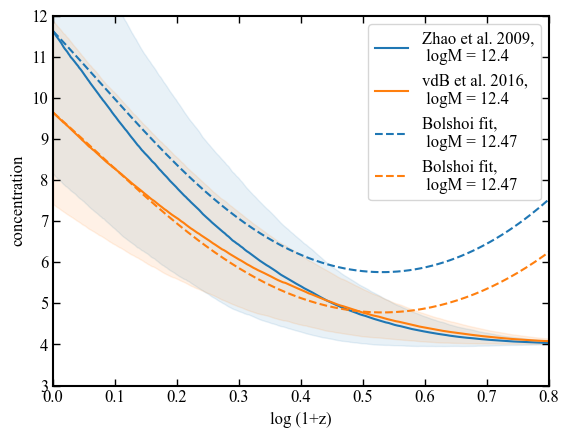

In [23]:
plt.plot(np.log10(1+zsample), mean_z, label="Zhao et al. 2009,\n logM = 12.4", color="C0")
plt.fill_between(np.log10(1+zsample), mean_z-std_z, mean_z+std_z, alpha=0.1, color="C0")

plt.plot(np.log10(1+vsample), mean_v, label="vdB et al. 2016,\n logM = 12.4", color="C1")
plt.fill_between(np.log10(1+vsample), mean_v-std_v, mean_v+std_v, alpha=0.1, color="C1")

plt.plot(np.log10(1+zsample), concentration(mean_z[0], zsample), ls="--", color="C0", label="Bolshoi fit,\n logM = 12.47")
plt.plot(np.log10(1+vsample), concentration(mean_v[0], vsample), ls="--", color="C1", label="Bolshoi fit,\n logM = 12.47")

plt.legend()
plt.ylim(3, 12)
plt.xlim(0, 0.8)
plt.xlabel("log (1+z)")
plt.ylabel("concentration")

Text(0, 0.5, 'concentration')

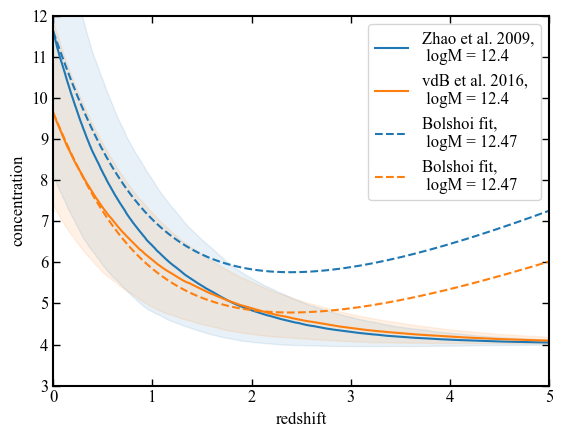

In [24]:
plt.plot(zsample, mean_z, label="Zhao et al. 2009,\n logM = 12.4", color="C0")
plt.fill_between(zsample, mean_z-std_z, mean_z+std_z, alpha=0.1, color="C0")

plt.plot(vsample, mean_v, label="vdB et al. 2016,\n logM = 12.4", color="C1")
plt.fill_between(vsample, mean_v-std_v, mean_v+std_v, alpha=0.1, color="C1")

plt.plot(zsample, concentration(mean_z[0], zsample), ls="--", color="C0", label="Bolshoi fit,\n logM = 12.47")
plt.plot(vsample, concentration(mean_v[0], vsample), ls="--", color="C1", label="Bolshoi fit,\n logM = 12.47")

plt.legend()
plt.ylim(3, 12)
plt.xlim(0, 5.0)
plt.xlabel("redshift")
plt.ylabel("concentration")

In [25]:
bol_pd = pd.read_csv("../../data/summary_tabs/BolshoiP_K.csv")
bolKnorm = jsm_simload.NormalizeData(bol_pd, dataset_title="BolshoiP_K")

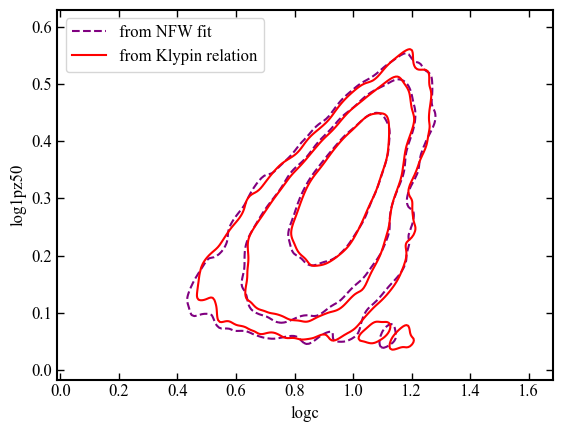

In [40]:
from matplotlib.lines import Line2D

sns.kdeplot(
    x=bolnorm.df["logc"],
    y=bolnorm.df["log1pz50"],
    levels=levelz,
    color="purple",
    linestyles="--",
)

sns.kdeplot(
    x=bolKnorm.df["logc"],
    y=bolKnorm.df["log1pz50"],
    levels=levelz,
    color="red",
)

handles = [
    Line2D([0], [0], color="purple", linestyle="--", label="from NFW fit"),
    Line2D([0], [0], color="red", linestyle="-", label="from Klypin relation"),
]

plt.legend(handles=handles, loc=2)
plt.show()

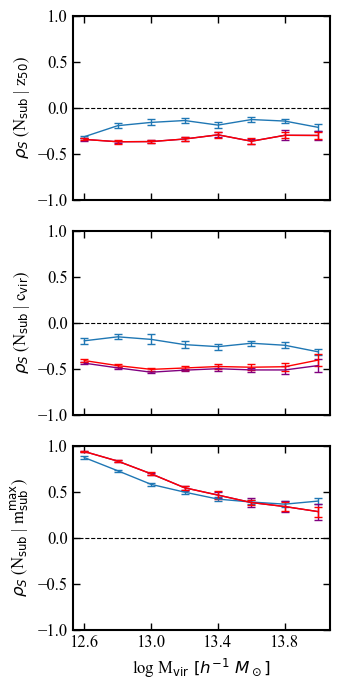

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [zhaonorm, bolnorm, bolKnorm]
colors = ["C0", "purple", "red"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()